In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [7]:
flights = pd.read_csv("C:/Users/AggelosMavraganis/githubproject/team2/csvfile/flight_delays.csv")
flights

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,NaN,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747622,1747623,United,4145,DFW,MIA,2024-09-01 12:46,2024-09-01 12:54,2024-09-01 17:46,2024-09-01 17:41,-5,NaN,False,True,Boeing 737,N19796,2396
1747623,1747624,United,2155,ATL,SEA,2024-09-01 20:43,2024-09-01 20:54,2024-09-01 21:43,2024-09-01 22:03,20,Weather,True,False,Boeing 777,N68154,2185
1747624,1747625,Delta,4878,JFK,SFO,2024-09-01 03:26,2024-09-01 03:47,2024-09-01 06:26,2024-09-01 06:20,-6,NaN,False,False,Boeing 777,N18964,361
1747625,1747626,Delta,2940,JFK,SEA,2024-09-01 08:04,2024-09-01 08:07,2024-09-01 13:04,2024-09-01 13:20,16,Maintenance,False,True,Airbus A320,N94591,2793


In [9]:
flights.describe()

,FlightID,FlightNumber,DelayMinutes,Distance
count,1.747627e+06,1.747627e+06,1.747627e+06,1.747627e+06
mean,8.738140e+05,5.001158e+03,9.999179e+00,1.549936e+03
std,5.044966e+05,2.885822e+03,1.183112e+01,8.368681e+02
min,1.000000e+00,1.000000e+00,-1.000000e+01,1.000000e+02
25%,4.369075e+05,2.503000e+03,0.000000e+00,8.250000e+02
50%,8.738140e+05,5.002000e+03,1.000000e+01,1.551000e+03
75%,1.310720e+06,7.499000e+03,2.000000e+01,2.274000e+03
max,1.747627e+06,9.999000e+03,3.000000e+01,3.000000e+03


In [10]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   FlightID            int64 
 1   Airline             object
 2   FlightNumber        int64 
 3   Origin              object
 4   Destination         object
 5   ScheduledDeparture  object
 6   ActualDeparture     object
 7   ScheduledArrival    object
 8   ActualArrival       object
 9   DelayMinutes        int64 
 10  DelayReason         object
 11  Cancelled           bool  
 12  Diverted            bool  
 13  AircraftType        object
 14  TailNumber          object
 15  Distance            int64 
dtypes: bool(2), int64(4), object(10)
memory usage: 190.0+ MB


In [11]:
flights.isnull().sum()

FlightID                   0
Airline                    0
FlightNumber               0
Origin                     0
Destination                0
ScheduledDeparture         0
ActualDeparture            0
ScheduledArrival           0
ActualArrival              0
DelayMinutes               0
DelayReason           468873
Cancelled                  0
Diverted                   0
AircraftType               0
TailNumber                 0
Distance                   0
dtype: int64

In [12]:
flights.fillna("No Delay Reason", inplace=True)

In [13]:
flights.head(100)

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,No Delay Reason,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Delta,8531,JFK,BOS,2024-09-01 00:35,2024-09-01 00:50,2024-09-01 02:35,2024-09-01 02:49,14,Air Traffic Control,True,True,Boeing 777,N49477,794
96,97,American Airlines,1655,ATL,SFO,2024-09-01 11:57,2024-09-01 12:19,2024-09-01 17:57,2024-09-01 18:25,28,Weather,True,True,Airbus A320,N17550,2948
97,98,United,8925,ATL,JFK,2024-09-01 22:50,2024-09-01 22:55,2024-09-02 03:50,2024-09-02 04:09,19,Weather,True,True,Boeing 777,N44017,1436
98,99,Delta,5930,LAX,SEA,2024-09-01 08:47,2024-09-01 08:52,2024-09-01 11:47,2024-09-01 12:08,21,Maintenance,False,False,Boeing 777,N70967,2608


In [14]:
flights['ScheduledDeparture'] = pd.to_datetime(flights['ScheduledDeparture'])
flights['ActualDeparture'] = pd.to_datetime(flights['ActualDeparture'])
flights['ScheduledArrival'] = pd.to_datetime(flights['ScheduledArrival'])
flights['ActualArrival'] = pd.to_datetime(flights['ActualArrival'])

In [15]:
flights.head(5)

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298


In [16]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Dtype         
---  ------              -----         
 0   FlightID            int64         
 1   Airline             object        
 2   FlightNumber        int64         
 3   Origin              object        
 4   Destination         object        
 5   ScheduledDeparture  datetime64[ns]
 6   ActualDeparture     datetime64[ns]
 7   ScheduledArrival    datetime64[ns]
 8   ActualArrival       datetime64[ns]
 9   DelayMinutes        int64         
 10  DelayReason         object        
 11  Cancelled           bool          
 12  Diverted            bool          
 13  AircraftType        object        
 14  TailNumber          object        
 15  Distance            int64         
dtypes: bool(2), datetime64[ns](4), int64(4), object(6)
memory usage: 190.0+ MB


In [31]:
flights["DepartureDiff"]= flights['ActualDeparture'] - flights['ScheduledDeparture']
flights['DepartureDiff'] = flights['DepartureDiff'] / pd.Timedelta(minutes=1)

In [32]:
flights.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance,DepartureDiff
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031,19.0
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006,16.0
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980,12.0
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408,20.0
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298,17.0


In [34]:
flights['DepartureDiff'] = flights['DepartureDiff'].astype(int)
flights.head(10)

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance,DepartureDiff
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031,19
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006,16
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980,12
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408,20
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298,17
5,6,Southwest,6311,LAX,JFK,2024-09-01 04:00:00,2024-09-01 04:12:00,2024-09-01 05:00:00,2024-09-01 04:55:00,-5,No Delay Reason,False,False,Boeing 777,N92652,1386,12
6,7,Southwest,4188,ORD,JFK,2024-09-01 05:47:00,2024-09-01 06:02:00,2024-09-01 10:47:00,2024-09-01 10:54:00,7,Weather,False,True,Boeing 777,N25382,1674,15
7,8,Southwest,3179,DFW,MIA,2024-09-01 02:23:00,2024-09-01 02:49:00,2024-09-01 06:23:00,2024-09-01 06:47:00,24,Weather,False,True,Boeing 777,N65410,2931,26
8,9,American Airlines,3613,ORD,MIA,2024-09-01 00:02:00,2024-09-01 00:29:00,2024-09-01 02:02:00,2024-09-01 02:04:00,2,Weather,False,False,Airbus A320,N45570,2337,27
9,10,Southwest,2186,LAX,BOS,2024-09-01 10:14:00,2024-09-01 10:39:00,2024-09-01 14:14:00,2024-09-01 14:39:00,25,Maintenance,True,False,Boeing 777,N15724,605,25


In [35]:
flights["ArrivalDelay"]   =((flights["ActualArrival"]   - flights["ScheduledArrival"]).dt.total_seconds() / 60).astype(int)

In [36]:
flights.head(10)

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance,DepartureDiff,ArrivalDelay
0,1,United,4558,ORD,MIA,2024-09-01 08:11:00,2024-09-01 08:30:00,2024-09-01 12:11:00,2024-09-01 12:19:00,8,Weather,True,False,Boeing 737,N71066,1031,19,8
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25:00,2024-09-01 10:41:00,2024-09-01 13:25:00,2024-09-01 13:27:00,2,Air Traffic Control,True,True,Airbus A320,N22657,1006,16,2
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53:00,2024-09-01 17:05:00,2024-09-01 17:53:00,2024-09-01 18:07:00,14,Weather,True,True,Boeing 737,N95611,2980,12,14
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44:00,2024-09-01 15:04:00,2024-09-01 18:44:00,2024-09-01 18:34:00,-10,No Delay Reason,False,False,Boeing 777,N90029,1408,20,-10
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51:00,2024-09-01 02:08:00,2024-09-01 05:51:00,2024-09-01 06:15:00,24,Air Traffic Control,False,True,Boeing 737,N27417,2298,17,24
5,6,Southwest,6311,LAX,JFK,2024-09-01 04:00:00,2024-09-01 04:12:00,2024-09-01 05:00:00,2024-09-01 04:55:00,-5,No Delay Reason,False,False,Boeing 777,N92652,1386,12,-5
6,7,Southwest,4188,ORD,JFK,2024-09-01 05:47:00,2024-09-01 06:02:00,2024-09-01 10:47:00,2024-09-01 10:54:00,7,Weather,False,True,Boeing 777,N25382,1674,15,7
7,8,Southwest,3179,DFW,MIA,2024-09-01 02:23:00,2024-09-01 02:49:00,2024-09-01 06:23:00,2024-09-01 06:47:00,24,Weather,False,True,Boeing 777,N65410,2931,26,24
8,9,American Airlines,3613,ORD,MIA,2024-09-01 00:02:00,2024-09-01 00:29:00,2024-09-01 02:02:00,2024-09-01 02:04:00,2,Weather,False,False,Airbus A320,N45570,2337,27,2
9,10,Southwest,2186,LAX,BOS,2024-09-01 10:14:00,2024-09-01 10:39:00,2024-09-01 14:14:00,2024-09-01 14:39:00,25,Maintenance,True,False,Boeing 777,N15724,605,25,25


In [106]:
TailnumberGrouped=flights.groupby("TailNumber")

In [119]:
TopTenPlanesDelays =TailnumberGrouped.mean("DepartureDiff").sort_values("DepartureDiff" , ascending= False).head(10)
TopTenPlanesDelays

,FlightID,FlightNumber,DelayMinutes,Cancelled,Diverted,Distance,DepartureDiff,ArrivalDelay
TailNumber,,,,,,,,
N73694,8.933598e+05,5608.000000,8.727273,0.454545,0.454545,1583.090909,24.636364,8.727273
N94190,8.321049e+05,5425.578947,8.526316,0.578947,0.526316,1407.473684,23.736842,8.526316
N93581,8.566961e+05,3996.214286,10.857143,0.500000,0.642857,1831.642857,23.714286,10.857143
N41512,8.428272e+05,4643.833333,12.833333,0.833333,0.333333,1676.916667,23.416667,12.833333
N48463,8.603815e+05,5571.454545,10.090909,0.454545,0.454545,1726.545455,23.363636,10.090909
N95561,9.618413e+05,5489.000000,10.727273,0.727273,0.454545,1768.818182,23.272727,10.727273
N29539,1.181425e+06,4063.384615,9.307692,0.384615,0.692308,1546.000000,23.230769,9.307692
N57137,1.097045e+06,5644.941176,4.588235,0.588235,0.647059,1668.294118,23.176471,4.588235
N48169,8.612908e+05,4616.437500,12.062500,0.500000,0.625000,1459.937500,23.062500,12.062500


<Axes: title={'center': 'Top 10 Planes with delays'}, xlabel='TailNumber', ylabel='Minutes Delay'>

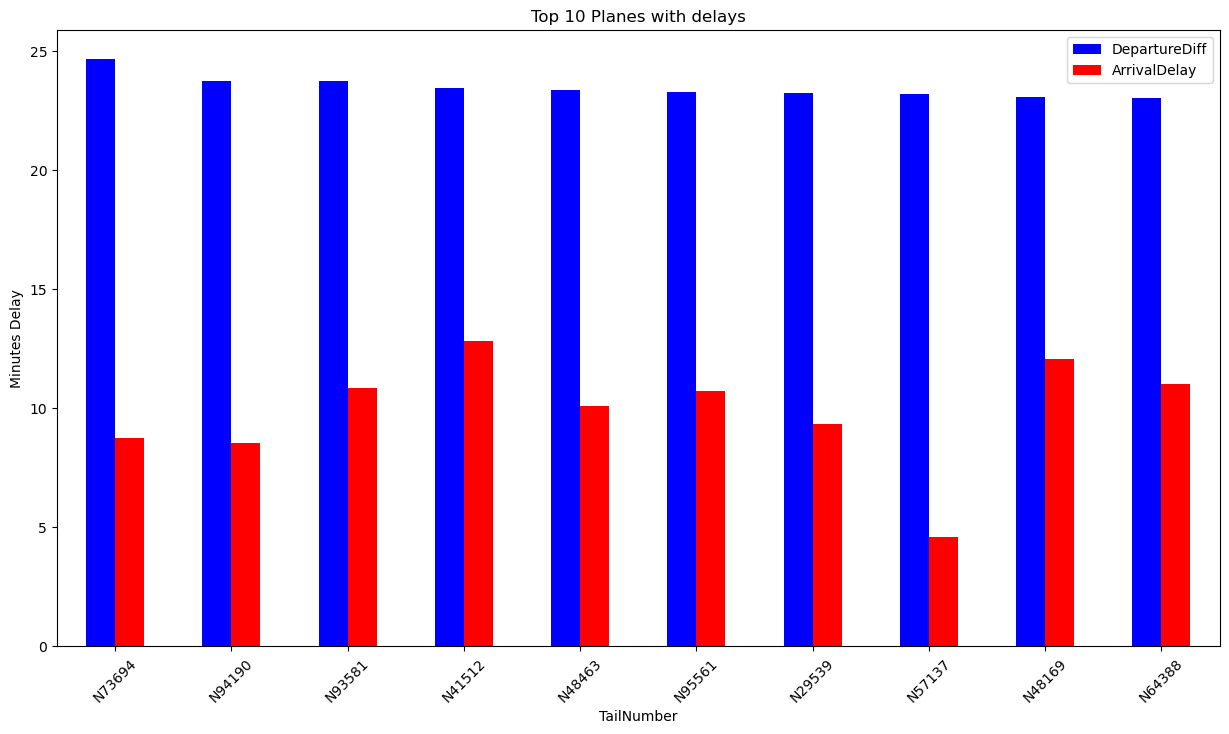

In [120]:
TopTenPlanesDelays.plot(y=['DepartureDiff','ArrivalDelay'],kind='bar',color=['blue','red'],title='Top 10 Planes with delays',ylabel='Minutes Delay',rot=45,figsize=(15, 8))

In [121]:
TopTenPlanesDelays=TopTenPlanesDelays.reset_index()

In [123]:
delayreason=flights[flights["TailNumber"].isin(TopTenPlanesDelays["TailNumber"])].groupby("DelayReason").count()
delayreason["TailNumber"].plot()

DelayReason
Air Traffic Control    35
Maintenance            31
No Delay Reason        43
Weather                29
Name: TailNumber, dtype: int64

<Axes: title={'center': 'Reason of delay for the top 10 most delayed planes'}, xlabel='DelayReason', ylabel='Delayed Flights'>

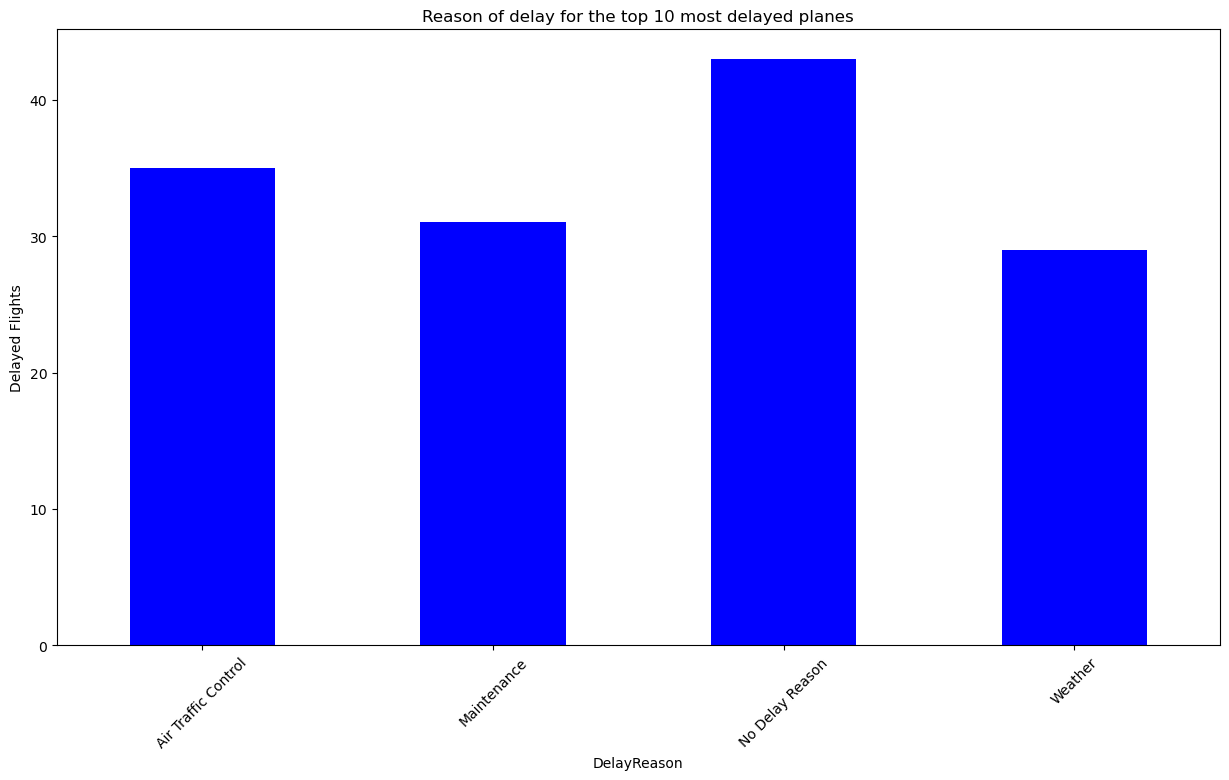

In [128]:
delayreason.plot(y="FlightID",kind='bar',color='blue',title='Reason of delay for the top 10 most delayed planes',ylabel='Delayed Flights',rot=45,figsize=(15, 8),legend=False)